Feature Importance  - General protective behaviour before mandates - covid model  

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

In [3]:
# downloadig data from the xgboost model code

# general protective behaviour before mandates train set
before_train_general_behav = pd.read_csv("before_train_general_behav.csv")

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date','face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
              'general_protective_behavior_binary','mandate_start_date']


# train set
x_train = before_train_general_behav.drop(columns=drop_cols)
x_train = x_train.astype(float)  # boolean to int

# target variable
y_train = before_train_general_behav["general_protective_behavior_binary"]


# best xgb hyper parameters
best_parameters = joblib.load("general_behav_before_covidModel_XGBoost_bestParameters_rolling.pkl")


In [4]:
best_parameters

{'xgb__learning_rate': 0.05,
 'xgb__max_depth': 5,
 'xgb__min_child_weight': 5,
 'xgb__n_estimators': 250}

100 runs to store all features

In [5]:
# to keep all the importances in each run
all_importances = []


for i in range(100):
    
    temp_xgb = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('xgb', XGBClassifier(random_state=i,
                              eval_metric='logloss',
                              n_jobs=-1))
        ])

    temp_xgb.set_params(**best_parameters)

    temp_xgb.fit(x_train, y_train)

    all_importances.append(temp_xgb.named_steps['xgb'].feature_importances_)

median - Feature Importance -  For stability

Feature Importance                                        Feature  Importance
6             protective_behavior_nomask_scale    0.580185
19                       state_New South Wales    0.017980
38    Pleasure in doing things_consent_removed    0.017441
40           Feeling down/depressed_Not at all    0.012877
56  How Government handle situation_Very badly    0.011231
0                       Non-household contacts    0.009791
8                          7days_rolling_cases    0.009659
60               comorbidities_consent_removed    0.009254
9                         7days_rolling_deaths    0.009196
7                                         week    0.009145
4                           Perceived Severity    0.009046
50           Can't control worrying_Not at all    0.008959
5                     Perceived Susceptibility    0.008860
57   How Government handle situation_Very well    0.008763
22                       state_South Australia    0.008440


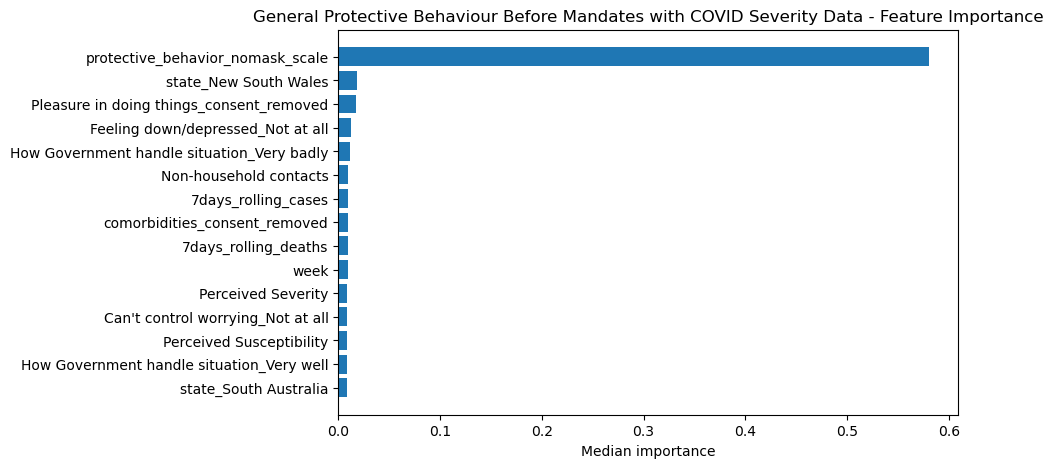

In [6]:
all_importances = np.array(all_importances)

# take the median / mean
median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})


feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
feature_importance.to_csv("general_behav_before_covidModel_XGBoost_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("General Protective Behaviour Before Mandates with COVID Severity Data - Feature Importance")
plt.xlabel("Median importance")
plt.gca().invert_yaxis()
plt.savefig("general_behav_before_covidModel_XGBoost_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()


mean - Feature Importance -  For stability

Feature Importance                                        Feature  Importance
6             protective_behavior_nomask_scale    0.580185
19                       state_New South Wales    0.017980
38    Pleasure in doing things_consent_removed    0.017441
40           Feeling down/depressed_Not at all    0.012877
56  How Government handle situation_Very badly    0.011231
0                       Non-household contacts    0.009791
8                          7days_rolling_cases    0.009659
60               comorbidities_consent_removed    0.009254
9                         7days_rolling_deaths    0.009196
7                                         week    0.009145
4                           Perceived Severity    0.009046
50           Can't control worrying_Not at all    0.008959
5                     Perceived Susceptibility    0.008860
57   How Government handle situation_Very well    0.008763
22                       state_South Australia    0.008440


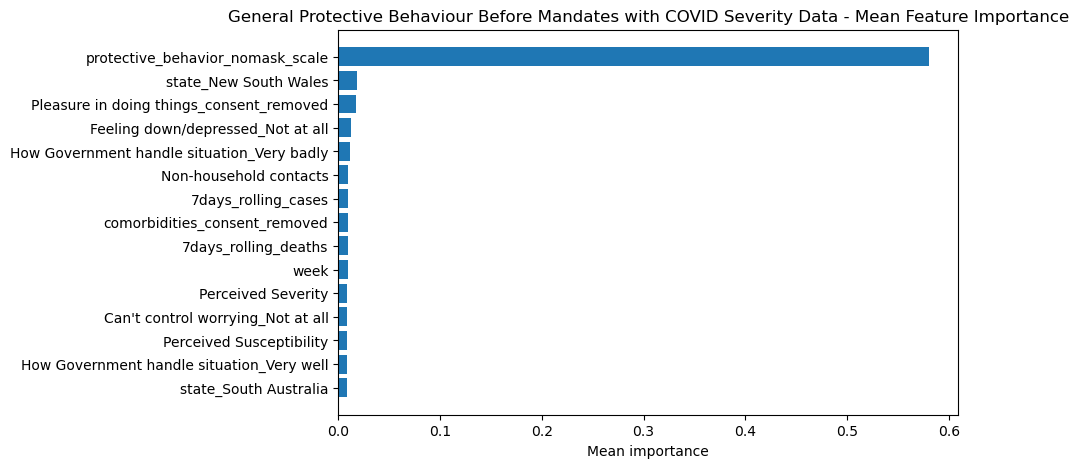

In [7]:
# take the mean
mean_importance = np.mean(all_importances, axis=0) # take the mean of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})

feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
# feature_importance.to_csv("facemask_before_covidModel_RF_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("General Protective Behaviour Before Mandates with COVID Severity Data - Mean Feature Importance")
plt.xlabel("Mean importance")
plt.gca().invert_yaxis()
plt.show()


# plt.tight_layout()
# plt.savefig("facemask_before_covidModel_RF_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")

Mean and Median Importance are similar.